# Score Differences

Where there any conversations where Maverick scored higher after we added Alexandria content?

In [5]:
import os
from pathlib import Path

import polars as pl
import seaborn as sns

from simple_evals.improvement.models.results import AllResults
from simple_evals.improvement.models.rag_logs import RAGLog
from simple_evals.improvement.paths import RESULTS_DIR
from simple_evals.improvement.input_getter import (
    EvalInputGetter,
    get_alexandria_document_by_case_id,
    RagLogGetter,
)

In [6]:
baseline_results_path = RESULTS_DIR / (
    "5df4ba309cb03369f6663786ae6a9904385524a9/"
    + "maverick/healthbench_llama-4-maverick_20251023_212754_allresults.json"
)
baseline_results = AllResults.from_file(baseline_results_path)


In [7]:
rag_run_dir = (
    RESULTS_DIR / "cbd99b81af7e1cb59d122dec8d0cb78717b8d10d/llama-4-maverick-rag2"
)
rag_results_path = (
    rag_run_dir / "healthbench_llama-4-maverick-rag2_20251120_175439_allresults.json"
)
rag_logs_dir = rag_run_dir / "rag_info"
rag_results = AllResults.from_file(rag_results_path)
rag_logs = RAGLog.from_log_dir(rag_logs_dir)

In [8]:
def flatten_metadata(results: AllResults, model_name: str) -> list[dict]:
    """
    Flattens the 'example_level_metadata' objects from the benchmark results file.
    """
    out = []
    for metadata in results.metadata.example_level_metadata:
        out.append(
            {
                "prompt_id": metadata.prompt_id,
                f"score_{model_name}": metadata.score,
            }
        )
    return out


def flatten_rag_logs(rag_logs: list[RAGLog]) -> list[dict]:
    """
    Flattens the rag_logs into dictionaries. It does this by leaving off the
    "conversations" key.
    """
    out = []
    for log in rag_logs:
        out.append(
            {
                "prompt_id": log.prompt_id,
                "vector_search_row_id": log.vector_search_row_id,
                "atropos_case_id": log.atropos_case_id,
                "similarity_score": log.similarity_score,
            }
        )
    return out

In [9]:
baseline = pl.DataFrame(flatten_metadata(baseline_results, "baseline"))
rag = pl.DataFrame(flatten_metadata(rag_results, "rag"))
rag_logs_df = pl.DataFrame(flatten_rag_logs(rag_logs))

In [10]:
combined = baseline.join(rag, on="prompt_id").join(rag_logs_df, on="prompt_id")
combined.head()

prompt_id,score_baseline,score_rag,vector_search_row_id,atropos_case_id,similarity_score
str,f64,f64,f64,str,f64
"""5ddbc2ae-a934-4aae-9631-45bac4…",0.583333,0.583333,9067.0,"""a7cade3239274a8d8cf9718c94f27f…",0.001871
"""9cdbd221-5495-4c79-a10a-f520a5…",-0.101695,-0.101695,7811.0,"""d347b503edc34ee8a6fff5f6a48f66…",0.001998
"""d5972228-1f8d-4f01-9ac0-548c5a…",0.303371,0.202247,2935.0,"""5650e71ea6db44368a377004ae9a58…",0.002235
"""681cc590-e662-432a-aa0d-b0e8a1…",0.017857,-0.053571,1275.0,"""7716f9896468440a98d5650f136fc6…",0.001632
"""108fa967-dd8f-4d93-905e-751d95…",1.0,1.0,43.0,"""2d96c9a70cc44f729510abece9c59c…",0.001594


In [11]:
sns.set_style("whitegrid")

In [12]:
diffs = combined.with_columns(
    # Calculate the difference between the runs for each question
    (pl.col("score_rag") - pl.col("score_baseline")).alias("effect_of_rag"),
    # Calculate the difference between the runs for each question
    (
        pl.when((pl.col("score_rag") - pl.col("score_baseline") > 0))
        .then(pl.lit("better"))
        .otherwise(pl.lit("worse"))
    ).alias("better_or_worse"),
)

In [21]:
diffs.select(pl.col("better_or_worse").value_counts()).unnest("better_or_worse")

better_or_worse,count
str,u32
"""better""",1521
"""worse""",3479


(-1.2, 1.2)

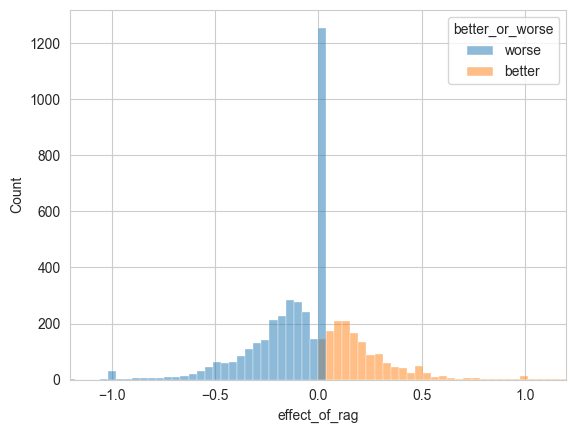

In [ ]:
g = sns.histplot(diffs, x="effect_of_rag", hue="better_or_worse")
g.set_xlim(-1.2, 1.2)

(-1.2, 1.2)

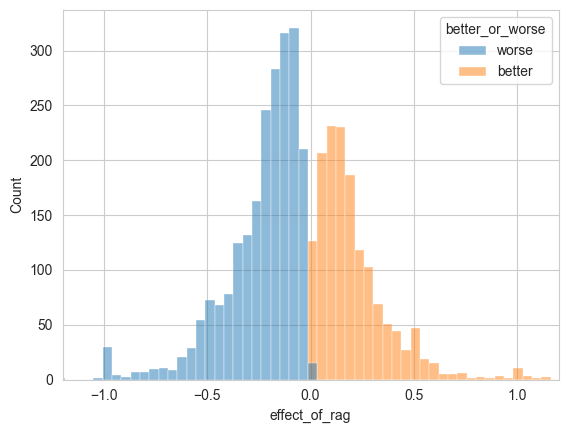

In [14]:
g = sns.histplot(
    diffs.filter(pl.col("effect_of_rag") != 0), x="effect_of_rag", hue="better_or_worse"
)
g.set_xlim(-1.2, 1.2)

Ladies and gentlemen, a bimodal distribution. I'm also seeing little bumps at -1 and 1. 

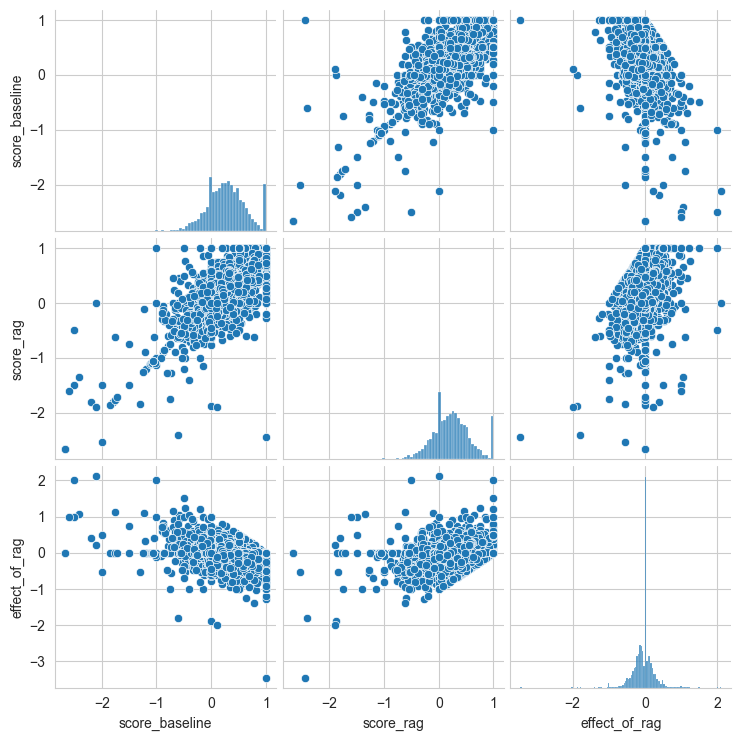

In [15]:
# What does the relationship look like between the baseline score, the rag
# score, and the difference between them?
sns.pairplot(diffs.select("score_baseline", "score_rag", "effect_of_rag").to_pandas())

Text(0, 0.5, 'Effect of Alexandria Content')

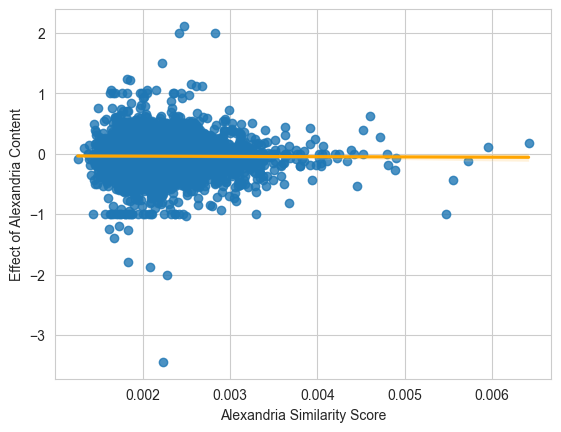

In [16]:
# Is there any relationship between the score difference and the vector similarity score?
g = sns.regplot(
    diffs, x="similarity_score", y="effect_of_rag", line_kws=dict(color="orange")
)
g.set_xlabel("Alexandria Similarity Score")
g.set_ylabel("Effect of Alexandria Content")

In [17]:
# Sample a few of the questions that improved and got worse with Alexandria content
better = diffs.filter(pl.col("effect_of_rag") > 0).sample(seed=42, n=10)
worse = diffs.filter(pl.col("effect_of_rag") < 0).sample(seed=42, n=10)

In [18]:
# os.environ["DATABRICKS_API_KEY"] = ""

In [19]:
better_dir = Path("./sampled/better")
worse_dir = Path("./sampled/worse")
eval_input_getter = EvalInputGetter()
rag_log_getter = RagLogGetter(
    RESULTS_DIR
    / ("cbd99b81af7e1cb59d122dec8d0cb78717b8d10d/llama-4-maverick-rag2/rag_info")
)

for prompt_id in better["prompt_id"]:
    inp = eval_input_getter.get_by_prompt_id(prompt_id)
    assert inp is not None
    output_path = better_dir / f"{prompt_id}.json"
    output_path.write_text(inp.model_dump_json(indent=2))
    case_id = rag_log_getter.get_case_id_for_prompt_id(prompt_id)
    document = get_alexandria_document_by_case_id(case_id)
    assert document is not None
    with output_path.open("a") as file:
        file.write("\n\n")
        file.write(f"Atropos Case ID: {document.case_id}\nContent: {document.content}")
for prompt_id in worse["prompt_id"]:
    inp = eval_input_getter.get_by_prompt_id(prompt_id)
    assert inp is not None
    output_path = worse_dir / f"{prompt_id}.json"
    output_path.write_text(inp.model_dump_json(indent=2))
    case_id = rag_log_getter.get_case_id_for_prompt_id(prompt_id)
    document = get_alexandria_document_by_case_id(case_id)
    assert document is not None
    with output_path.open("a") as file:
        file.write("\n\n")
        file.write(f"Atropos Case ID: {document.case_id}\nContent: {document.content}")